В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os

from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, learning_curve, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [2]:
%load_ext autoreload
%autoreload 2

from data.process_bank_churn import preprocess_data

In [3]:
raw_df = pd.read_csv("data/train.csv", index_col=0)
data = preprocess_data(raw_df)

In [4]:
(
    X_train, y_train,
    X_val, y_val,
    input_cols, numeric_cols, categorical_cols,
    imputer, scaler, encoder
) = preprocess_data(raw_df)

In [5]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,,,,,,,,,,,,,
7180,0.599045,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [6]:
knn = KNeighborsClassifier()

In [7]:
%%time
knn.fit(X_train, y_train)

CPU times: total: 31.2 ms
Wall time: 32.4 ms


KNeighborsClassifier()

In [8]:
# Прогнози ймовірностей
train_pred = knn.predict_proba(X_train)[:, 1]
val_pred = knn.predict_proba(X_val)[:, 1]

# AUC
train_auc = roc_auc_score(y_train, train_pred)
val_auc = roc_auc_score(y_val, val_pred)

print("AUC train:", train_auc)
print("AUC val:  ", val_auc)

AUC train: 0.9559428457733543
AUC val:   0.852585568283147


**Висновок:**
У нас різниця:
0.9559-0.8526 = 0.1033 — це помірний розрив.
Модель загалом непогана. Валідаційний AUC 0.85 — це хороший рівень.
Є ознаки перенавчання high variance, але не катастрофічні.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [10]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 35)}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_gs = GridSearchCV(knn, params_knn, cv=cv)
knn_gs.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34])})

In [11]:
knn_gs.best_estimator_

KNeighborsClassifier(n_neighbors=np.int64(7))

In [12]:
print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(7)} 0.8676666666666666


In [13]:
knn_best = knn_gs.best_estimator_

In [14]:
# Прогнози ймовірностей
train_pred = knn_best.predict_proba(X_train)[:, 1]
val_pred = knn_best.predict_proba(X_val)[:, 1]

# AUC
train_auc = roc_auc_score(y_train, train_pred)
val_auc = roc_auc_score(y_val, val_pred)

print("AUC train:", train_auc)
print("AUC val:  ", val_auc)

AUC train: 0.9472239316872085
AUC val:   0.8678266684957814


**Висновок:**
Модель стала кращою після GridSearchCV
- Валідаційний AUC зріс
- Перенавчання зменшилось
- Модель стала більш узагальнюючою
  
**DecisionTreeClassifier**(max_depth=5, random_state=42):
- AUC train: 0.9257
- AUC val:   0.9219

**Порівняння**
- Дерево рішень значно краще на валідації (0.922 vs 0.868).
- Дерево стабільніше (мінімальний розрив train–val).
- kNN має помітно нижчу якість узагальнення.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [15]:
# 1. Модель з фіксованим random_state
dec_tree = DecisionTreeClassifier(random_state=42)

# 2. Сітка гіперпараметрів
params_dec_tree = {
    'max_depth': np.arange(1, 21, 2),        # 1,3,5,...,19
    'max_leaf_nodes': np.arange(2, 11, 1)    # 2–10 'max_leaf_nodes': np.arange(2, 40, 4)
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. GridSearchCV
dec_tree_gs = GridSearchCV(
    estimator=dec_tree,
    param_grid=params_dec_tree,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    refit=True
)

In [16]:
%%time
# 4. Навчання
dec_tree_gs.fit(X_train, y_train)

CPU times: total: 1.5 s
Wall time: 7.03 s


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='roc_auc')

In [17]:
dec_tree_gs.best_estimator_

DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=np.int64(10),
                       random_state=42)

In [21]:
print(dec_tree_gs.best_params_, dec_tree_gs.best_score_)

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)} 0.899241048958563


In [22]:
dt_best = dec_tree_gs.best_estimator_

In [23]:
# Прогнози ймовірностей
train_pred = dt_best.predict_proba(X_train)[:, 1]
val_pred = dt_best.predict_proba(X_val)[:, 1]

# AUC
train_auc = roc_auc_score(y_train, train_pred)
val_auc = roc_auc_score(y_val, val_pred)

print("AUC train:", train_auc)
print("AUC val:  ", val_auc)

AUC train: 0.9014754782174744
AUC val:   0.9002184649152891


**Висновок:**
- Ручне дерево має вищий AUC (≈0.92 проти ≈0.90)
- Але GridSearchCV‑дерево більш регуляризоване
- Воно менше перенавчене, але й менш точне
  
**DecisionTreeClassifier** (ручний підбір) (max_depth=5, random_state=42):
- AUC train: 0.9257
- AUC val:   0.9219

**Загальний висновок**

Модель після GridSearchCV:
- стабільна
- добре узагальнює
- не перенавчена
- але трохи гірша за якістю, ніж дерево, знайдене вручну

Ручне дерево:
- має вищий AUC
- теж не перенавчене
- загалом краще підходить для задачі

**Додатково**
Можна розширити сітку параметрів пошуку і отримати той самий результат, що вручну, тестувала, працює.
З практичних кейсів рідко обмежують ці два параметри одночасно, або якщо і обмежують то в певному співвідношенні.
Як висновок для себе взяла, що після перших результатів грід пошуку варто експерементувати з сіткою гіперпараметрів.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [24]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [25]:
# 1. Модель з фіксованим random_state
dt = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 2. RandomizedSearchCV
dt_random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=params_dt,
    n_iter=40,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

In [26]:
%%time
# 4. Навчання
dt_random_search.fit(X_train, y_train)

CPU times: total: 875 ms
Wall time: 4.24 s


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=DecisionTreeClassifier(random_state=42), n_iter=40,
                   n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [27]:
dt_random_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(16),
                       max_leaf_nodes=np.int64(14), min_samples_leaf=2,
                       min_samples_split=20, random_state=42)

In [28]:
print(dt_random_search.best_params_, dt_random_search.best_score_)

{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'} 0.9102569441552492


In [29]:
dt_random_search_best = dt_random_search.best_estimator_

In [30]:
# Прогнози ймовірностей
train_pred = dt_random_search_best.predict_proba(X_train)[:, 1]
val_pred = dt_random_search_best.predict_proba(X_val)[:, 1]

# AUC
train_auc = roc_auc_score(y_train, train_pred)
val_auc = roc_auc_score(y_val, val_pred)

print("AUC train:", train_auc)
print("AUC val:  ", val_auc)

AUC train: 0.9169275635848141
AUC val:   0.9166204815145071


**Порівняння параметрів**

dt_best (GridSearchCV):
- max_depth = 5 — обмежений
- max_leaf_nodes = 10 — обмежений
- інші параметри — за замовченням
Це робить дерево простим і регуляризованим, але менш гнучким.

dt_random_search_best (RandomizedSearchCV):
- max_depth = 16 → значно глибше дерево
- max_leaf_nodes = 14 → більше кінцевих рішень
- min_samples_split = 20 → сильна регуляризація
- min_samples_leaf = 2 → запобігає дрібним листкам
- criterion = entropy → інколи дає кращі розділення
- splitter = best → стабільніший поділ
  
**Висновок:**
- RandomizedSearchCV дав кращу модель, ніж GridSearchCV (AUC val: GridSearch ≈ 0.900, RandomizedSearch ≈ 0.917)
- Модель стала глибшою, але не перенавченою завдяки min_samples_split і min_samples_leaf.
- Параметри суттєво відрізняються:
- GridSearch обмежував дерево занадто сильно → нижчий AUC.
- RandomizedSearch дозволив дереву бути гнучкішим → вищий AUC.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

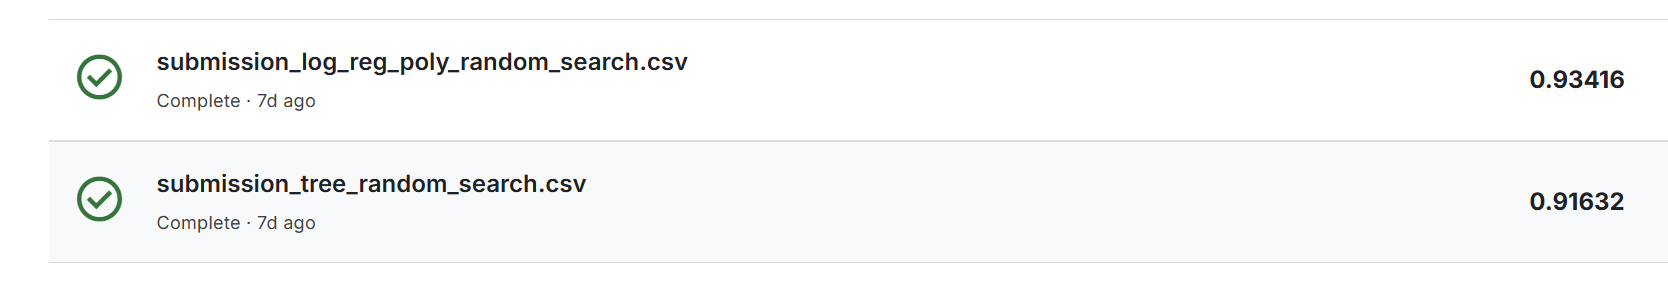

In [31]:
from data.process_bank_churn import preprocess_new_data

In [32]:
test_df = pd.read_csv("data/test.csv")
test_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [33]:
X_test = preprocess_new_data(
    new_df=test_df,
    input_cols=input_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    imputer=imputer,
    scaler=scaler,
    encoder=encoder
)

In [34]:
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,0.365155,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,0.0,1.0,0.0,0.0,1.0
1,0.286396,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,1.0,0.0,0.0,0.0,1.0
2,0.656325,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,1.0,0.0,0.0,0.0,1.0
3,0.682578,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,0.0,1.0,0.0,1.0
4,0.384248,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,0.0,1.0,0.0,1.0


In [35]:
test_pred = dt_random_search_best.predict_proba(X_test)[:, 1]

In [36]:
test_df['Exited'] = dt_random_search_best.predict_proba(X_test)[:, 1]

In [37]:
test_df['Exited']

0       0.237911
1       0.012115
2       0.203947
3       0.569848
4       0.082171
          ...   
9995    0.012115
9996    0.012115
9997    0.012115
9998    0.039301
9999    0.187638
Name: Exited, Length: 10000, dtype: float64

In [38]:
submission = pd.read_csv("data/sample_submission.csv")

In [39]:
submission.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [40]:
submission['Exited'] = test_df['Exited']

In [41]:
submission.head()

,id,Exited
0,15000,0.237911
1,15001,0.012115
2,15002,0.203947
3,15003,0.569848
4,15004,0.082171


In [42]:
submission.to_csv("data/submission_tree_random_search.csv", index=False)